# LLM Model Evaluation — Standard Metrics Comparison
Parse `metrics.txt` and display **Accuracy, Precision, Recall, F1** for all five models (QWEN, Gemma, Llama, Phi, Mistral) in a unified format using majority-vote results.

## Open Models

In [28]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# ── QWEN: all 3 runs are identical; use any run's values ─────────────────────
# Values read from metrics.txt
qwen = dict(model="QWEN", accuracy=0.5300, precision=0.3103, recall=0.2500, f1=0.2769)

# ── Gemma: majority_vote row from CSV block ───────────────────────────────────
gemma = dict(model="Gemma", accuracy=0.65, precision=0.6667, recall=0.0556, f1=0.1026)

# ── Llama: majority vote ──────────────────────────────────────────────────────
llama = dict(model="Llama", accuracy=0.3800, precision=0.3556, recall=0.8889, f1=0.5079)

# ── Phi: majority vote ────────────────────────────────────────────────────────
phi = dict(model="Phi", accuracy=0.6500, precision=1.0000, recall=0.0278, f1=0.0541)

# ── Mistral: majority_vote row from CSV block ─────────────────────────────────
mistral = dict(model="Mistral", accuracy=0.65, precision=0.6667, recall=0.0556, f1=0.1026)

# ── Build unified DataFrame ───────────────────────────────────────────────────
df = pd.DataFrame([qwen, gemma, llama, phi, mistral])
df = df.set_index("model")
df.columns = ["Accuracy", "Precision", "Recall", "F1 Score"]

print("=" * 60)
print("  Standard Metrics — All Models (Majority Vote)")
print("=" * 60)
print(df.to_string(float_format=lambda x: f"{x:.4f}"))
print()

  Standard Metrics — All Models (Majority Vote)
         Accuracy  Precision  Recall  F1 Score
model                                         
QWEN       0.5300     0.3103  0.2500    0.2769
Gemma      0.6500     0.6667  0.0556    0.1026
Llama      0.3800     0.3556  0.8889    0.5079
Phi        0.6500     1.0000  0.0278    0.0541
Mistral    0.6500     0.6667  0.0556    0.1026



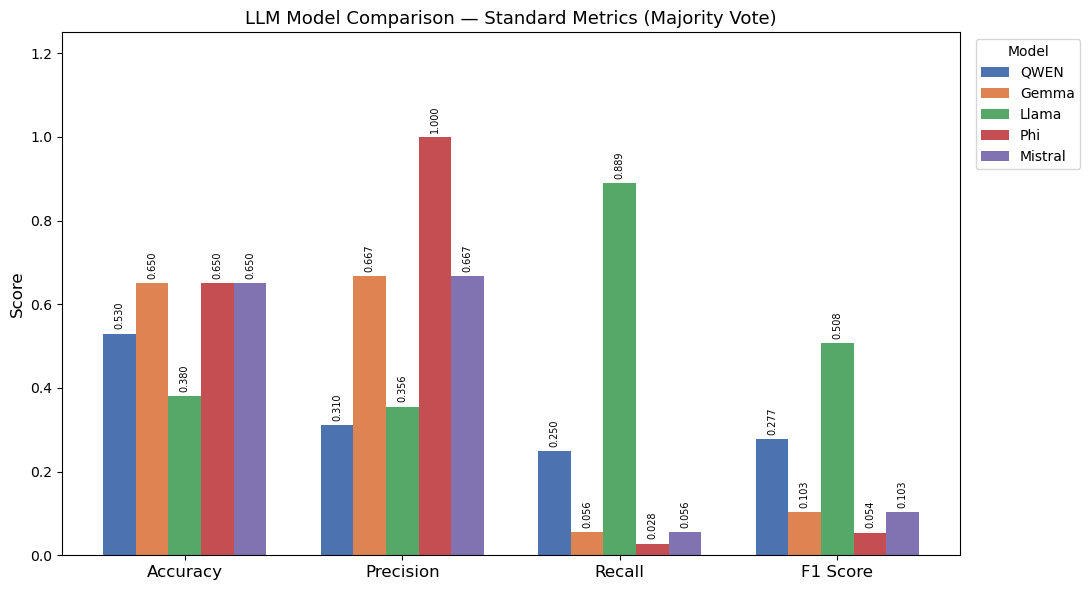

In [29]:
metrics   = ["Accuracy", "Precision", "Recall", "F1 Score"]
models    = df.index.tolist()
colors    = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

x     = range(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(11, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    offsets = [xi + (i - len(models) / 2) * width + width / 2 for xi in x]
    bars = ax.bar(offsets, df.loc[model], width, label=model, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7, rotation=90)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.25)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("LLM Model Comparison — Standard Metrics (Majority Vote)", fontsize=13)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Closed Models — Prompt Experiment Metrics
Visualize **Gemini** and **OpenAI** across prompt styles (`rules` / `simple`) and shot counts (0–3).

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_exp = pd.read_csv("closed_models/100_sample_1_prompt_experiment_metrics.csv")
df_exp["label"] = df_exp["prompt_style"] + "-" + df_exp["shots"].astype(int).astype(str) + "shot"

print(df_exp[["model_name", "label", "accuracy", "precision", "recall", "f1"]].to_string(index=False))

model_name        label  accuracy  precision   recall       f1
    gemini  rules-0shot      0.82   0.704545 0.861111 0.775000
    gemini  rules-1shot      0.84   0.916667 0.611111 0.733333
    gemini  rules-2shot      0.83   0.806452 0.694444 0.746269
    gemini  rules-3shot      0.83   0.880000 0.611111 0.721311
    gemini simple-0shot      0.71   0.571429 0.777778 0.658824
    gemini simple-1shot      0.72   0.653846 0.472222 0.548387
    gemini simple-2shot      0.72   0.681818 0.416667 0.517241
    gemini simple-3shot      0.75   0.677419 0.583333 0.626866
    openai  rules-0shot      0.86   1.000000 0.611111 0.758621
    openai  rules-1shot      0.78   1.000000 0.388889 0.560000
    openai  rules-2shot      0.76   1.000000 0.333333 0.500000
    openai  rules-3shot      0.77   1.000000 0.361111 0.530612
    openai simple-0shot      0.78   0.733333 0.611111 0.666667
    openai simple-1shot      0.78   0.888889 0.444444 0.592593
    openai simple-2shot      0.69   1.000000 0.138889 0

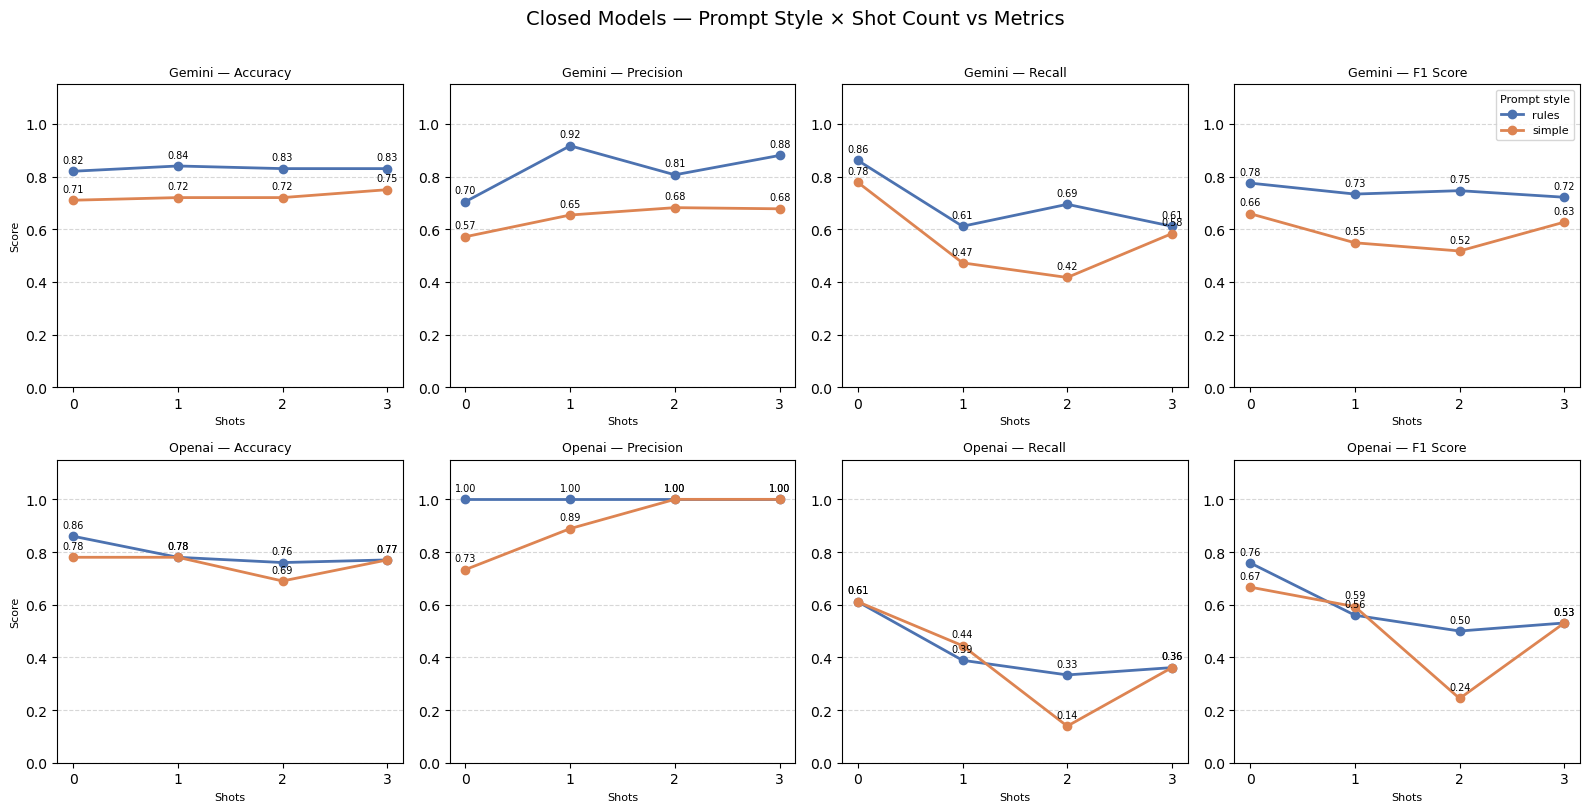

In [31]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
metric_labels   = ["Accuracy", "Precision", "Recall", "F1 Score"]
models          = df_exp["model_name"].unique()          # gemini, openai
prompt_styles   = ["rules", "simple"]
style_colors    = {"rules": "#4C72B0", "simple": "#DD8452"}
shot_markers    = {0: "o", 1: "s", 2: "^", 3: "D"}

fig, axes = plt.subplots(
    nrows=len(models), ncols=len(metrics_to_plot),
    figsize=(16, 8), sharey=False
)
fig.suptitle("Closed Models — Prompt Style × Shot Count vs Metrics", fontsize=14, y=1.01)

for row, model in enumerate(models):
    df_m = df_exp[df_exp["model_name"] == model]
    for col, (metric, mlabel) in enumerate(zip(metrics_to_plot, metric_labels)):
        ax = axes[row, col]
        for style in prompt_styles:
            df_s = df_m[df_m["prompt_style"] == style].sort_values("shots")
            ax.plot(df_s["shots"], df_s[metric],
                    marker="o", label=style,
                    color=style_colors[style], linewidth=2, markersize=6)
            for _, r in df_s.iterrows():
                ax.annotate(f"{r[metric]:.2f}",
                            (r["shots"], r[metric]),
                            textcoords="offset points", xytext=(0, 6),
                            ha="center", fontsize=7)
        ax.set_title(f"{model.capitalize()} — {mlabel}", fontsize=9)
        ax.set_xlabel("Shots", fontsize=8)
        ax.set_xticks([0, 1, 2, 3])
        ax.set_ylim(0, 1.15)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        if col == 0:
            ax.set_ylabel("Score", fontsize=8)
        if row == 0 and col == len(metrics_to_plot) - 1:
            ax.legend(title="Prompt style", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

## Open vs Closed Models — Head-to-Head Comparison
Open models use **majority vote** results. Closed models use the **best F1 configuration** per model (annotated on the chart).

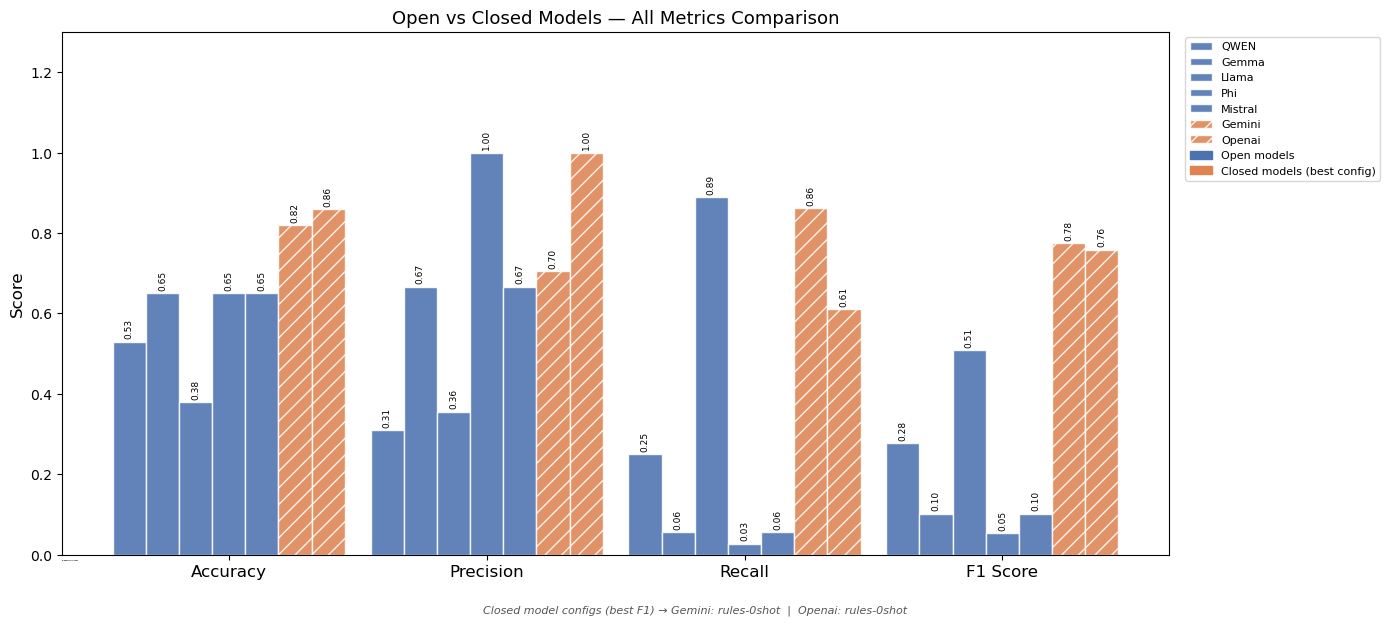

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Open models (majority vote) ───────────────────────────────────────────────
open_models = pd.DataFrame([
    dict(model="QWEN",    accuracy=0.5300, precision=0.3103, recall=0.2500, f1=0.2769),
    dict(model="Gemma",   accuracy=0.6500, precision=0.6667, recall=0.0556, f1=0.1026),
    dict(model="Llama",   accuracy=0.3800, precision=0.3556, recall=0.8889, f1=0.5079),
    dict(model="Phi",     accuracy=0.6500, precision=1.0000, recall=0.0278, f1=0.0541),
    dict(model="Mistral", accuracy=0.6500, precision=0.6667, recall=0.0556, f1=0.1026),
]).set_index("model")
open_models["group"] = "Open"

# ── Closed models: best-F1 config per model ───────────────────────────────────
df_exp = pd.read_csv("closed_models/100_sample_1_prompt_experiment_metrics.csv")
best_closed = (
    df_exp.loc[df_exp.groupby("model_name")["f1"].idxmax()]
    .copy()
)
best_closed["model"] = best_closed["model_name"].str.capitalize()
best_closed["best_config"] = best_closed["prompt_style"] + "-" + best_closed["shots"].astype(int).astype(str) + "shot"
best_closed = best_closed.set_index("model")[["accuracy", "precision", "recall", "f1", "best_config"]]
best_closed["group"] = "Closed"

# ── Combine ───────────────────────────────────────────────────────────────────
combined = pd.concat([open_models, best_closed[["accuracy", "precision", "recall", "f1", "group"]]])
combined.index.name = "model"

metrics      = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
all_models   = combined.index.tolist()
group_color  = {"Open": "#4C72B0", "Closed": "#DD8452"}
bar_colors   = [group_color[combined.loc[m, "group"]] for m in all_models]
# Lighten closed bars with hatch to distinguish individual models
hatches      = ["" if combined.loc[m, "group"] == "Open" else "//" for m in all_models]

x     = np.arange(len(metrics))
width = 0.9 / len(all_models)

fig, ax = plt.subplots(figsize=(14, 6))

for i, model in enumerate(all_models):
    offsets = x + (i - len(all_models) / 2) * width + width / 2
    bars = ax.bar(offsets, combined.loc[model, metrics], width,
                  label=model, color=bar_colors[i],
                  hatch=hatches[i], edgecolor="white", alpha=0.88)
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=6.5, rotation=90)

# Closed-model config annotations below x-axis
for model in best_closed.index:
    cfg = best_closed.loc[model, "best_config"]
    ax.annotate(f"★ {model}: {cfg}", xy=(0, 0), xycoords="axes fraction",
                xytext=(0, -0.01), textcoords="axes fraction",
                ha="left", fontsize=0)  # placeholder — printed below

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.3)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Open vs Closed Models — All Metrics Comparison", fontsize=13)

# Legend: group patches + individual model entries
open_patch   = mpatches.Patch(color="#4C72B0", label="Open models")
closed_patch = mpatches.Patch(color="#DD8452", hatch="//", label="Closed models (best config)")
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles=handles + [open_patch, closed_patch],
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# Config note below chart
config_note = "  |  ".join(
    [f"{m}: {best_closed.loc[m, 'best_config']}" for m in best_closed.index]
)
fig.text(0.5, -0.03, f"Closed model configs (best F1) → {config_note}",
         ha="center", fontsize=8, style="italic", color="#555555")

plt.tight_layout()
plt.show()

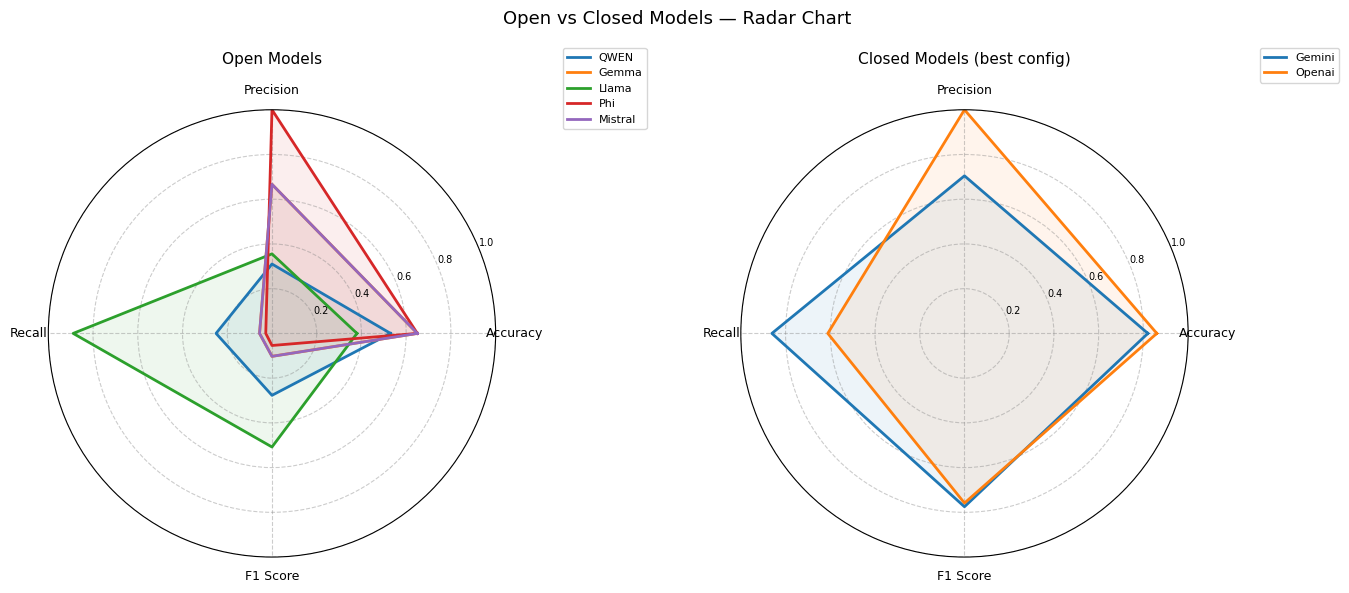

In [33]:
from matplotlib.patches import FancyArrowPatch

# ── Radar / Spider chart ──────────────────────────────────────────────────────
categories   = ["Accuracy", "Precision", "Recall", "F1 Score"]
N            = len(categories)
angles       = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles      += angles[:1]   # close the loop

palette = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw=dict(polar=True))
fig.suptitle("Open vs Closed Models — Radar Chart", fontsize=13)

for ax, (group_label, group_df) in zip(axes, [("Open Models", open_models),
                                               ("Closed Models (best config)", best_closed)]):
    ax.set_title(group_label, size=11, pad=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=7)
    ax.grid(color="grey", linestyle="--", alpha=0.4)

    for idx, (model, row) in enumerate(group_df.iterrows()):
        values = [row["accuracy"], row["precision"], row["recall"], row["f1"]]
        values += values[:1]
        color = palette[idx % len(palette)]
        ax.plot(angles, values, color=color, linewidth=2, label=model)
        ax.fill(angles, values, color=color, alpha=0.08)

    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.tight_layout()
plt.show()

## NLI Pipeline — Ablation & Model Comparison
Two NLI backbone models (**DeBERTa-v3** and **RoBERTa-large**) evaluated across a 5-stage pipeline.  
Metrics shown: Accuracy, Precision, Recall, F1 Score, Balanced Accuracy.

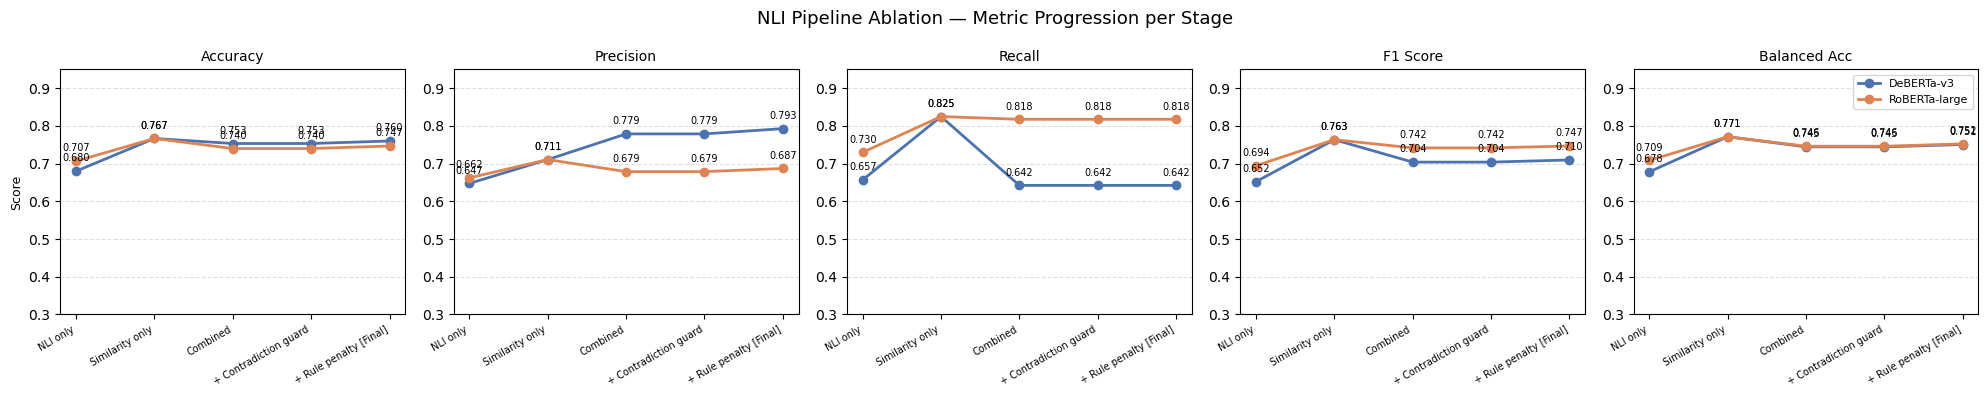

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Ablation data parsed from nli/nli_metrics.txt ────────────────────────────
# Precision = TP/(TP+FP), Recall = TP/(TP+FN)  computed from the ablation table
stages = [
    "NLI only",
    "Similarity only",
    "Combined",
    "+ Contradiction guard",
    "+ Rule penalty [Final]",
]

deberta = pd.DataFrame({
    "stage":     stages,
    "acc":       [0.6800, 0.7667, 0.7533, 0.7533, 0.7600],
    "precision": [0.6475, 0.7107, 0.7788, 0.7788, 0.7928],  # TP/(TP+FP)
    "recall":    [0.6569, 0.8248, 0.6423, 0.6423, 0.6423],  # TP/(TP+FN)
    "f1":        [0.6522, 0.7635, 0.7040, 0.7040, 0.7097],
    "bal_acc":   [0.6782, 0.7713, 0.7445, 0.7445, 0.7506],
}).set_index("stage")

roberta = pd.DataFrame({
    "stage":     stages,
    "acc":       [0.7067, 0.7667, 0.7400, 0.7400, 0.7467],
    "precision": [0.6623, 0.7107, 0.6788, 0.6788, 0.6871],  # TP/(TP+FP)
    "recall":    [0.7299, 0.8248, 0.8175, 0.8175, 0.8175],  # TP/(TP+FN)
    "f1":        [0.6944, 0.7635, 0.7417, 0.7417, 0.7467],
    "bal_acc":   [0.7085, 0.7713, 0.7462, 0.7462, 0.7523],
}).set_index("stage")

metrics       = ["acc", "precision", "recall", "f1", "bal_acc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score", "Balanced Acc"]
model_data    = {"DeBERTa-v3": deberta, "RoBERTa-large": roberta}
model_colors  = {"DeBERTa-v3": "#4C72B0", "RoBERTa-large": "#DD8452"}

# ── Plot 1: Ablation line chart — one subplot per metric ─────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
fig.suptitle("NLI Pipeline Ablation — Metric Progression per Stage", fontsize=13)

for ax, metric, mlabel in zip(axes, metrics, metric_labels):
    for name, df_nli in model_data.items():
        ax.plot(range(len(stages)), df_nli[metric],
                marker="o", linewidth=2, markersize=6,
                color=model_colors[name], label=name)
        for i, val in enumerate(df_nli[metric]):
            ax.annotate(f"{val:.3f}", (i, val),
                        textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7)
    ax.set_title(mlabel, fontsize=10)
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, rotation=30, ha="right", fontsize=7)
    ax.set_ylim(0.3, 0.95)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if ax is axes[0]:
        ax.set_ylabel("Score", fontsize=9)
    if ax is axes[-1]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

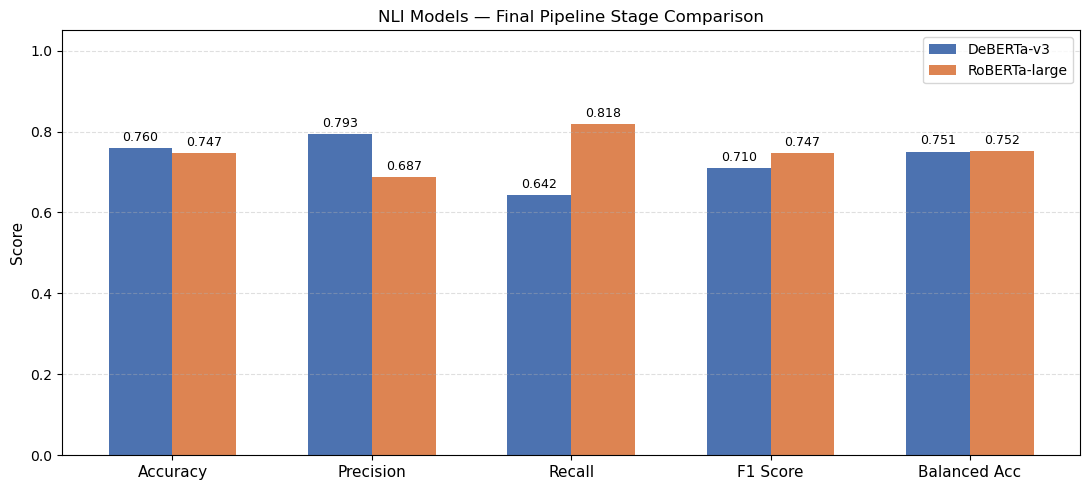

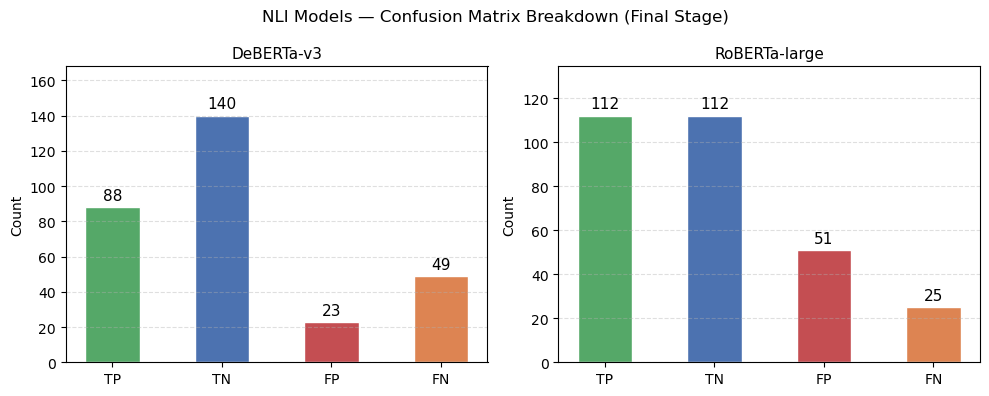

In [35]:
# ── Plot 2: Final stage — grouped bar comparison between the two models ───────
final_data = pd.DataFrame({
    "Metric":        metric_labels,
    "DeBERTa-v3":    [deberta.loc["+ Rule penalty [Final]", m] for m in metrics],
    "RoBERTa-large": [roberta.loc["+ Rule penalty [Final]", m] for m in metrics],
})

x     = np.arange(len(metric_labels))
width = 0.32

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width / 2, final_data["DeBERTa-v3"],   width, label="DeBERTa-v3",    color="#4C72B0")
b2 = ax.bar(x + width / 2, final_data["RoBERTa-large"], width, label="RoBERTa-large", color="#DD8452")
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("NLI Models — Final Pipeline Stage Comparison", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 3: Confusion matrix breakdown (TP/TN/FP/FN) at Final stage ──────────
cm_data = {
    "DeBERTa-v3":    dict(TP=88, TN=140, FP=23, FN=49),
    "RoBERTa-large": dict(TP=112, TN=112, FP=51, FN=25),
}
cm_labels = ["TP", "TN", "FP", "FN"]
cm_colors = ["#55A868", "#4C72B0", "#C44E52", "#DD8452"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("NLI Models — Confusion Matrix Breakdown (Final Stage)", fontsize=12)

for ax, (model, counts) in zip(axes, cm_data.items()):
    vals = [counts[k] for k in cm_labels]
    bars = ax.bar(cm_labels, vals, color=cm_colors, edgecolor="white", width=0.5)
    ax.bar_label(bars, padding=3, fontsize=11)
    ax.set_title(model, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.2)
    ax.set_ylabel("Count", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

---
## RQ1: Baseline Performance of Transformer-Based Models

> *To what extent can standard transformer-based models accurately detect semantic similarity between app features in user reviews using vector-based distance metrics?*

The **"Similarity only"** row represents the pure sentence-embedding baseline (`all-MiniLM-L6-v2`). Both NLI backbone experiments share the same embedding model, so the baseline is identical.  
Charts: (1) all metrics at baseline stage, (2) Precision–Recall position relative to all pipeline stages.

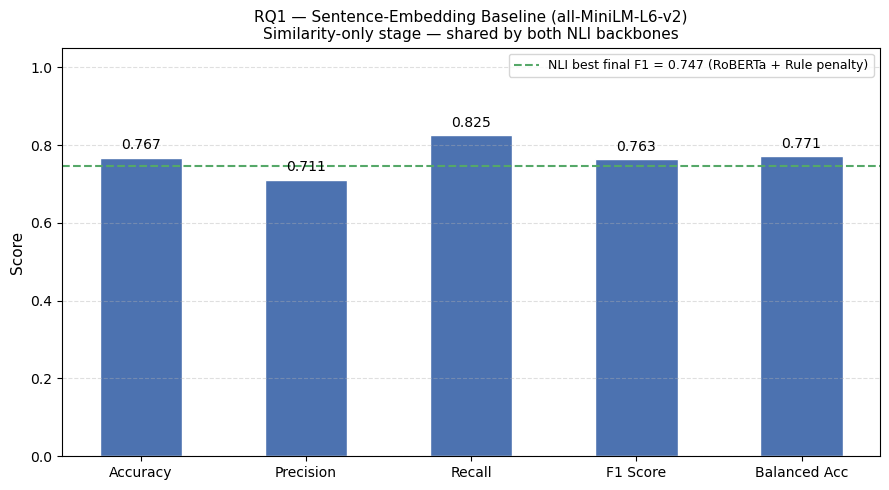

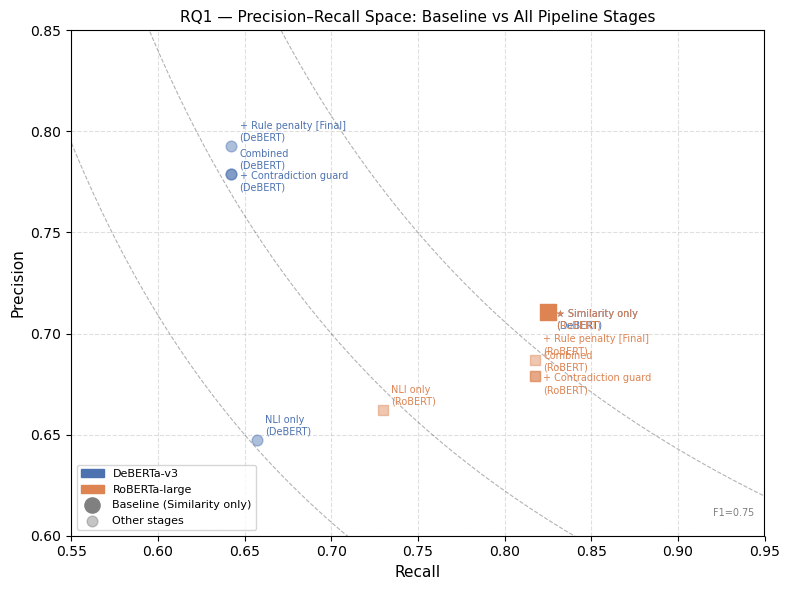

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Shared data (re-declared so this cell is self-contained) ─────────────────
stages = [
    "NLI only", "Similarity only", "Combined",
    "+ Contradiction guard", "+ Rule penalty [Final]",
]
deberta_data = {
    "acc":       [0.6800, 0.7667, 0.7533, 0.7533, 0.7600],
    "precision": [0.6475, 0.7107, 0.7788, 0.7788, 0.7928],
    "recall":    [0.6569, 0.8248, 0.6423, 0.6423, 0.6423],
    "f1":        [0.6522, 0.7635, 0.7040, 0.7040, 0.7097],
    "bal_acc":   [0.6782, 0.7713, 0.7445, 0.7445, 0.7506],
}
roberta_data = {
    "acc":       [0.7067, 0.7667, 0.7400, 0.7400, 0.7467],
    "precision": [0.6623, 0.7107, 0.6788, 0.6788, 0.6871],
    "recall":    [0.7299, 0.8248, 0.8175, 0.8175, 0.8175],
    "f1":        [0.6944, 0.7635, 0.7417, 0.7417, 0.7467],
    "bal_acc":   [0.7085, 0.7713, 0.7462, 0.7462, 0.7523],
}

# Baseline = "Similarity only" (index 1) — same for both backbones
baseline_idx  = 1
rq1_metrics   = ["acc", "precision", "recall", "f1", "bal_acc"]
rq1_labels    = ["Accuracy", "Precision", "Recall", "F1 Score", "Balanced Acc"]
baseline_vals = [deberta_data[m][baseline_idx] for m in rq1_metrics]   # identical for both

# Best final-stage F1 across both NLI pipelines (RoBERTa, Rule penalty)
nli_best_final_f1 = 0.7467

# ── Chart 1: Baseline metric bar chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rq1_labels, baseline_vals, color="#4C72B0", edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "RQ1 — Sentence-Embedding Baseline (all-MiniLM-L6-v2)\n"
    "Similarity-only stage — shared by both NLI backbones",
    fontsize=11,
)
ax.axhline(nli_best_final_f1, color="#55A868", linestyle="--", linewidth=1.5,
           label=f"NLI best final F1 = {nli_best_final_f1:.3f} (RoBERTa + Rule penalty)")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Chart 2: Precision–Recall scatter — all stages, both models ──────────────
fig, ax = plt.subplots(figsize=(8, 6))
model_styles = {
    "DeBERTa-v3":   {"color": "#4C72B0", "marker": "o"},
    "RoBERTa-large":{"color": "#DD8452", "marker": "s"},
}
for model_name, data in [("DeBERTa-v3", deberta_data), ("RoBERTa-large", roberta_data)]:
    col  = model_styles[model_name]["color"]
    mark = model_styles[model_name]["marker"]
    for i, stage in enumerate(stages):
        alpha = 1.0 if i == baseline_idx else 0.45
        size  = 120  if i == baseline_idx else 60
        ax.scatter(data["recall"][i], data["precision"][i],
                   color=col, marker=mark, s=size, alpha=alpha, zorder=3)
        ax.annotate(
            f"{'★ ' if i == baseline_idx else ''}{stage}\n({model_name[:6]})",
            (data["recall"][i], data["precision"][i]),
            textcoords="offset points",
            xytext=(6, 4 if i % 2 == 0 else -12),
            fontsize=7, color=col,
        )

# Iso-F1 curves
for f1_val in [0.65, 0.70, 0.75]:
    r_vals = np.linspace(0.01, 1.0, 200)
    p_vals = f1_val * r_vals / (2 * r_vals - f1_val)
    p_vals = np.where((p_vals >= 0) & (p_vals <= 1), p_vals, np.nan)
    ax.plot(r_vals, p_vals, "k--", linewidth=0.8, alpha=0.3)
    ax.annotate(f"F1={f1_val}", (0.92, f1_val / (2 - f1_val) + 0.01), fontsize=7, color="grey")

legend_handles = [
    mpatches.Patch(color="#4C72B0", label="DeBERTa-v3"),
    mpatches.Patch(color="#DD8452", label="RoBERTa-large"),
    plt.scatter([], [], color="grey", s=120, label="Baseline (Similarity only)"),
    plt.scatter([], [], color="grey", s=60, alpha=0.45, label="Other stages"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower left")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_xlim(0.55, 0.95)
ax.set_ylim(0.60, 0.85)
ax.set_title("RQ1 — Precision–Recall Space: Baseline vs All Pipeline Stages", fontsize=11)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

---
## RQ2: Efficacy of NLI Reformulation

> *How does reformulating feature similarity detection as a Natural Language Inference (NLI) task affect the precision and recall compared to traditional sentence-embedding approaches?*

Charts: (1) Grouped bar — NLI-only vs Similarity-only precision & recall for each backbone, (2) full ablation progression of precision & recall across all 5 stages.

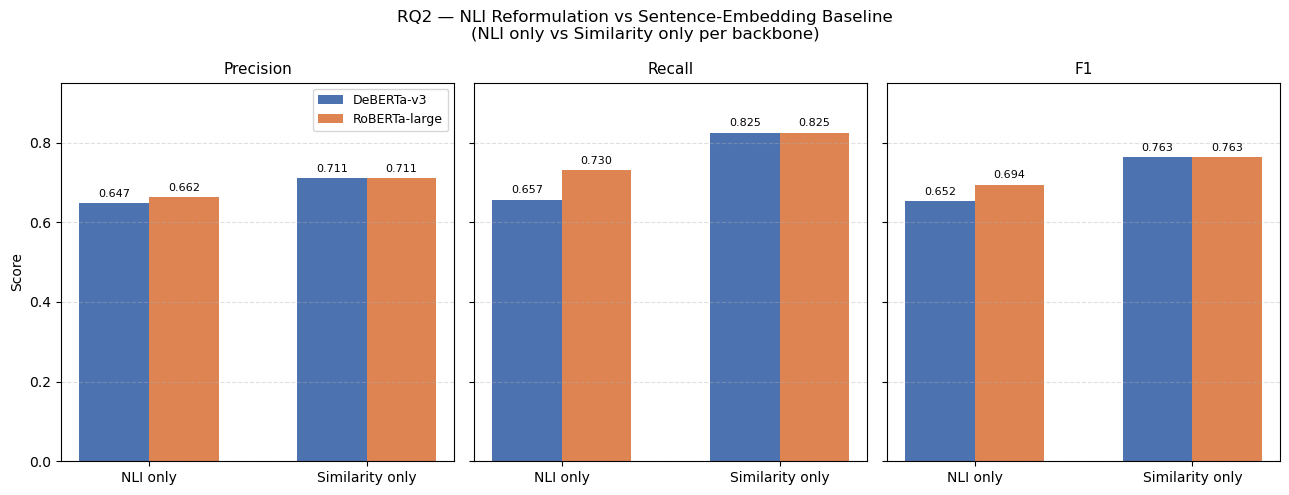

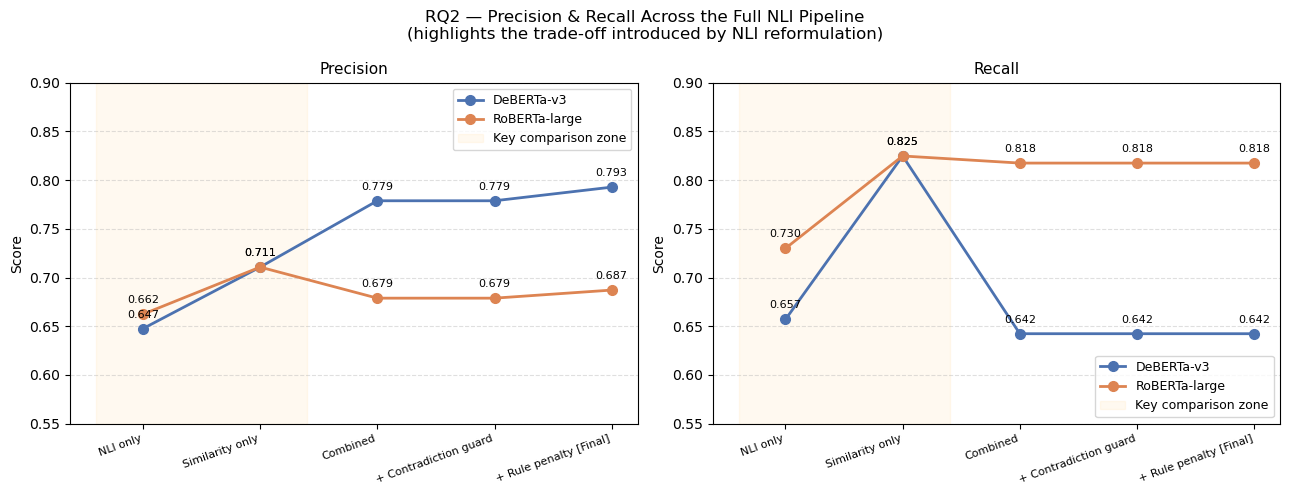

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stages = [
    "NLI only", "Similarity only", "Combined",
    "+ Contradiction guard", "+ Rule penalty [Final]",
]
deberta_data = {
    "precision": [0.6475, 0.7107, 0.7788, 0.7788, 0.7928],
    "recall":    [0.6569, 0.8248, 0.6423, 0.6423, 0.6423],
    "f1":        [0.6522, 0.7635, 0.7040, 0.7040, 0.7097],
}
roberta_data = {
    "precision": [0.6623, 0.7107, 0.6788, 0.6788, 0.6871],
    "recall":    [0.7299, 0.8248, 0.8175, 0.8175, 0.8175],
    "f1":        [0.6944, 0.7635, 0.7417, 0.7417, 0.7467],
}
model_colors = {"DeBERTa-v3": "#4C72B0", "RoBERTa-large": "#DD8452"}

# ── Chart 1: NLI-only vs Similarity-only — Precision, Recall, F1 ─────────────
compare_stages   = ["NLI only", "Similarity only"]
compare_metrics  = ["precision", "recall", "f1"]
compare_labels   = ["Precision", "Recall", "F1"]
compare_idx      = [0, 1]   # positions in stages list

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig.suptitle(
    "RQ2 — NLI Reformulation vs Sentence-Embedding Baseline\n"
    "(NLI only vs Similarity only per backbone)",
    fontsize=12,
)
bar_w = 0.32
x = np.arange(len(compare_stages))

for ax, metric, mlabel in zip(axes, compare_metrics, compare_labels):
    for j, (model_name, data) in enumerate([("DeBERTa-v3", deberta_data),
                                             ("RoBERTa-large", roberta_data)]):
        vals  = [data[metric][i] for i in compare_idx]
        shift = (j - 0.5) * bar_w
        bars  = ax.bar(x + shift, vals, bar_w,
                       label=model_name, color=model_colors[model_name])
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_title(mlabel, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(compare_stages, fontsize=10)
    ax.set_ylim(0, 0.95)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if ax is axes[0]:
        ax.set_ylabel("Score", fontsize=10)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Chart 2: Full precision & recall progression across all 5 stages ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "RQ2 — Precision & Recall Across the Full NLI Pipeline\n"
    "(highlights the trade-off introduced by NLI reformulation)",
    fontsize=12,
)
for ax, metric, mlabel in zip(axes, ["precision", "recall"], ["Precision", "Recall"]):
    for model_name, data in [("DeBERTa-v3", deberta_data), ("RoBERTa-large", roberta_data)]:
        vals = data[metric]
        ax.plot(range(len(stages)), vals,
                marker="o", linewidth=2, markersize=7,
                color=model_colors[model_name], label=model_name)
        for i, v in enumerate(vals):
            ax.annotate(f"{v:.3f}", (i, v),
                        textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=8)
    # Shade the "NLI only" vs "Similarity only" gap
    ax.axvspan(-0.4, 1.4, alpha=0.06, color="orange", label="Key comparison zone")
    ax.set_title(mlabel, fontsize=11)
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, rotation=20, ha="right", fontsize=8)
    ax.set_ylim(0.55, 0.90)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylabel("Score", fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## RQ3: Comparative Evaluation of LLMs and In-Context Learning

> *How do open-source and closed-source LLMs compare in their ability to identify feature similarity using zero-shot and few-shot prompting, and do they outperform NLI-based methods?*

Charts: (1) F1 bar chart — all LLMs vs NLI best as reference line, (2) zero-shot vs few-shot breakdown for closed models, (3) full metrics radar comparing every approach.

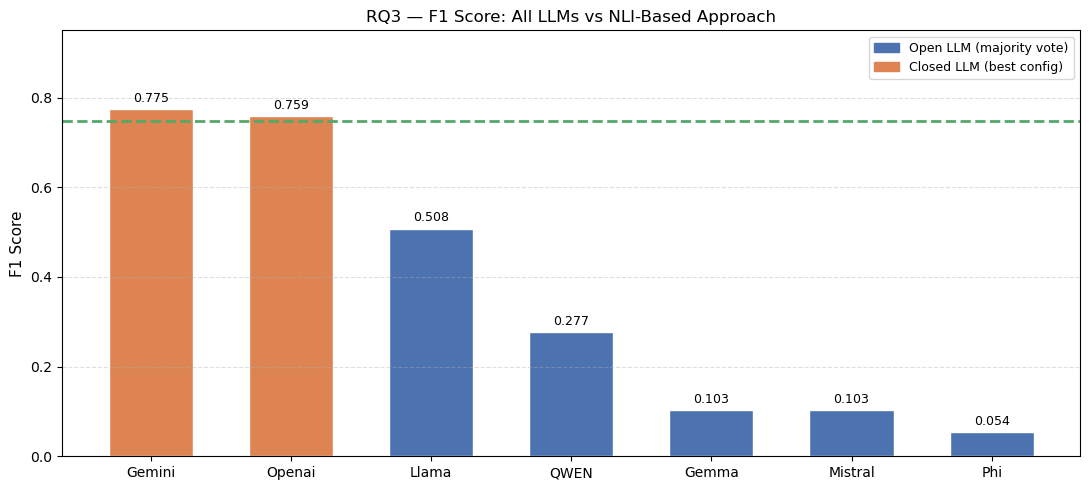

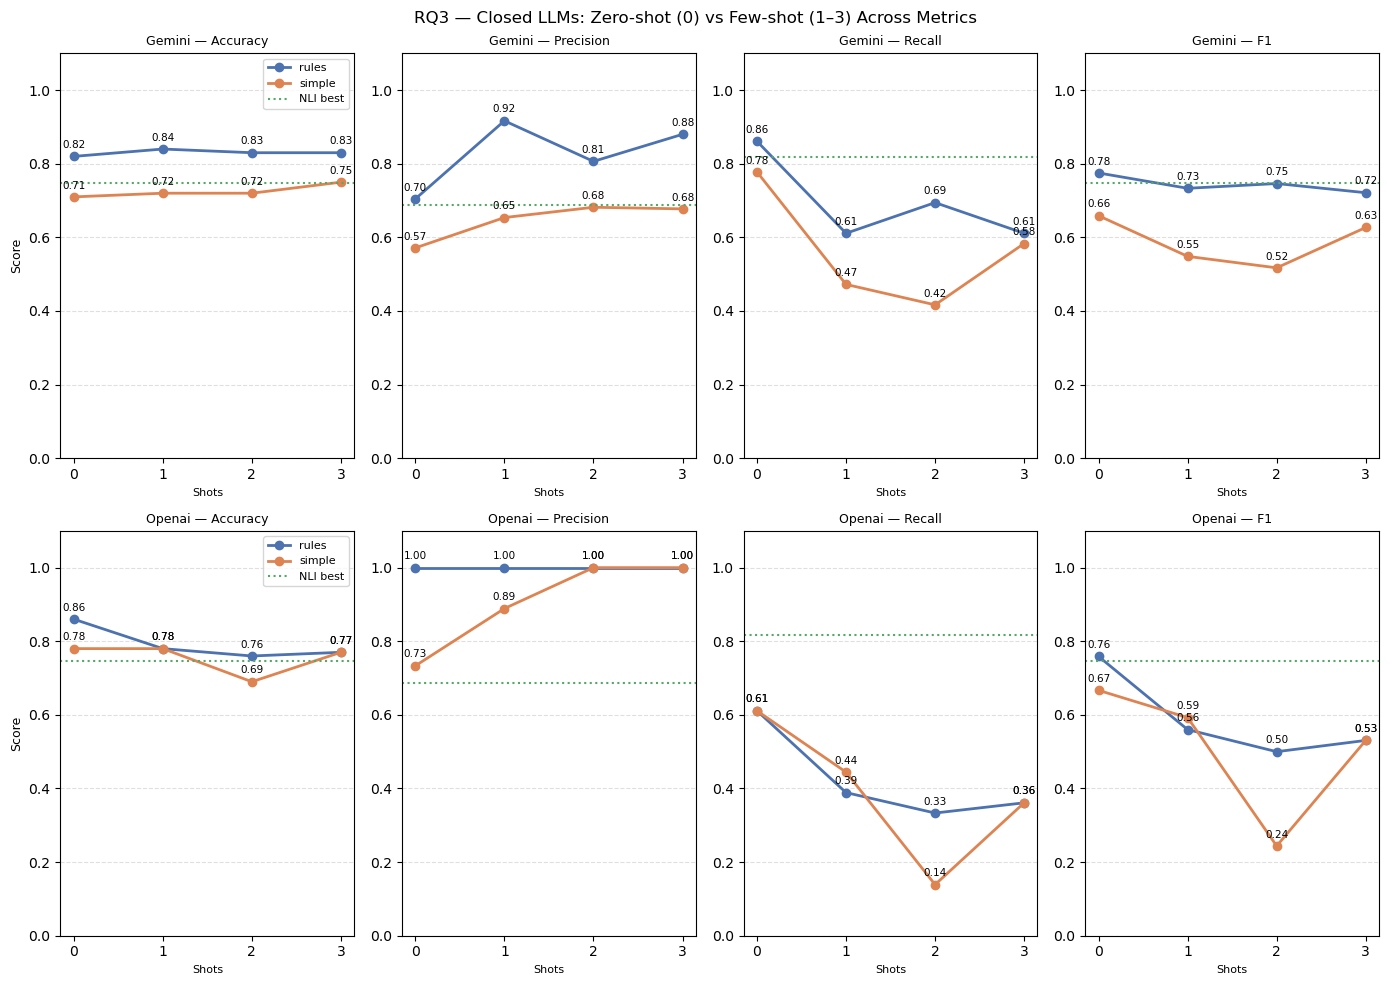

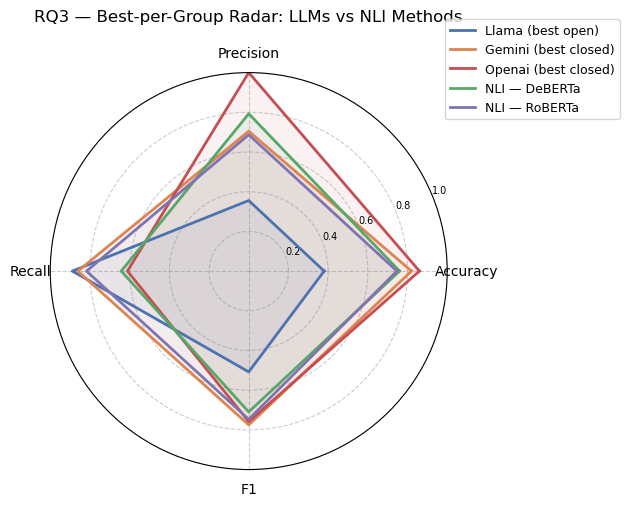

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── All model data ────────────────────────────────────────────────────────────
# Open LLMs (majority vote)
open_llms = pd.DataFrame([
    dict(model="QWEN",    group="Open LLM",   accuracy=0.5300, precision=0.3103, recall=0.2500, f1=0.2769),
    dict(model="Gemma",   group="Open LLM",   accuracy=0.6500, precision=0.6667, recall=0.0556, f1=0.1026),
    dict(model="Llama",   group="Open LLM",   accuracy=0.3800, precision=0.3556, recall=0.8889, f1=0.5079),
    dict(model="Phi",     group="Open LLM",   accuracy=0.6500, precision=1.0000, recall=0.0278, f1=0.0541),
    dict(model="Mistral", group="Open LLM",   accuracy=0.6500, precision=0.6667, recall=0.0556, f1=0.1026),
]).set_index("model")

# Closed LLMs — best F1 config per model
df_exp    = pd.read_csv("closed_models/100_sample_1_prompt_experiment_metrics.csv")
best_cls  = df_exp.loc[df_exp.groupby("model_name")["f1"].idxmax()].copy()
best_cls["model"]      = best_cls["model_name"].str.capitalize()
best_cls["group"]      = "Closed LLM"
best_cls["best_shots"] = best_cls["shots"].astype(int)
best_cls              = best_cls.set_index("model")[["group", "accuracy", "precision", "recall", "f1", "best_shots", "prompt_style"]]

# NLI best (RoBERTa Final stage — highest F1 of the two)
nli_best_f1  = 0.7467
nli_best_acc = 0.7467
nli_best_pre = 0.6871
nli_best_rec = 0.8175
NLI_LABEL    = "NLI Best\n(RoBERTa+Rule)"

group_colors = {"Open LLM": "#4C72B0", "Closed LLM": "#DD8452", "NLI": "#55A868"}

# ── Chart 1: F1 bar chart — all LLMs + NLI reference line ───────────────────
all_f1 = pd.concat([
    open_llms[["group", "f1"]],
    best_cls[["group", "f1"]],
])
order  = all_f1["f1"].sort_values(ascending=False).index
all_f1 = all_f1.loc[order]
colors = [group_colors[all_f1.loc[m, "group"]] for m in all_f1.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(all_f1)), all_f1["f1"], color=colors, edgecolor="white", width=0.6)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.axhline(nli_best_f1, color=group_colors["NLI"], linestyle="--", linewidth=2,
           label=f"NLI Best F1 = {nli_best_f1:.3f} (RoBERTa + Rule penalty)")
ax.set_xticks(range(len(all_f1)))
ax.set_xticklabels(all_f1.index, fontsize=10)
ax.set_ylim(0, 0.95)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("RQ3 — F1 Score: All LLMs vs NLI-Based Approach", fontsize=12)
open_p   = mpatches.Patch(color="#4C72B0", label="Open LLM (majority vote)")
closed_p = mpatches.Patch(color="#DD8452", label="Closed LLM (best config)")
ax.legend(handles=[open_p, closed_p], fontsize=9, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Chart 2: Zero-shot vs few-shot — closed models, all metrics ──────────────
metrics_c  = ["accuracy", "precision", "recall", "f1"]
mlabels_c  = ["Accuracy", "Precision", "Recall", "F1"]
closed_models_names = df_exp["model_name"].unique()

fig, axes = plt.subplots(len(closed_models_names), len(metrics_c),
                         figsize=(14, 5 * len(closed_models_names)), sharey=False)
if len(closed_models_names) == 1:
    axes = axes[np.newaxis, :]
fig.suptitle("RQ3 — Closed LLMs: Zero-shot (0) vs Few-shot (1–3) Across Metrics", fontsize=12)

style_colors = {"rules": "#4C72B0", "simple": "#DD8452"}
for row_i, mdl in enumerate(closed_models_names):
    df_m = df_exp[df_exp["model_name"] == mdl]
    for col_i, (metric, mlabel) in enumerate(zip(metrics_c, mlabels_c)):
        ax = axes[row_i, col_i]
        for style in ["rules", "simple"]:
            df_s = df_m[df_m["prompt_style"] == style].sort_values("shots")
            ax.plot(df_s["shots"].astype(int), df_s[metric],
                    marker="o", linewidth=2, label=style,
                    color=style_colors[style])
            for _, r in df_s.iterrows():
                ax.annotate(f"{r[metric]:.2f}", (int(r["shots"]), r[metric]),
                            textcoords="offset points", xytext=(0, 6),
                            ha="center", fontsize=7.5)
        # NLI reference
        ax.axhline({"accuracy": nli_best_acc, "precision": nli_best_pre,
                    "recall": nli_best_rec, "f1": nli_best_f1}[metric],
                   color=group_colors["NLI"], linestyle=":", linewidth=1.5,
                   label="NLI best" if col_i == 0 else "_")
        ax.set_title(f"{mdl.capitalize()} — {mlabel}", fontsize=9)
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xlabel("Shots", fontsize=8)
        ax.set_ylim(0, 1.1)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        if col_i == 0:
            ax.set_ylabel("Score", fontsize=9)
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Chart 3: Radar — all approaches (best per group) + NLI ───────────────────
radar_data = {
    "Llama (best open)":    [0.3800, 0.3556, 0.8889, 0.5079],
    "Gemini (best closed)": list(best_cls.loc["Gemini", ["accuracy", "precision", "recall", "f1"]]),
    "Openai (best closed)": list(best_cls.loc["Openai", ["accuracy", "precision", "recall", "f1"]]),
    "NLI — DeBERTa":        [0.7600, 0.7928, 0.6423, 0.7097],
    "NLI — RoBERTa":        [0.7467, 0.6871, 0.8175, 0.7467],
}
cat    = ["Accuracy", "Precision", "Recall", "F1"]
N      = len(cat)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
palette = ["#4C72B0", "#DD8452", "#C44E52", "#55A868", "#8172B2"]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_title("RQ3 — Best-per-Group Radar: LLMs vs NLI Methods", fontsize=12, pad=18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cat, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
ax.grid(color="grey", linestyle="--", alpha=0.4)

for (label, vals), color in zip(radar_data.items(), palette):
    v = vals + [vals[0]]
    ax.plot(angles, v, color=color, linewidth=2, label=label)
    ax.fill(angles, v, color=color, alpha=0.07)

ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.15), fontsize=9)
plt.tight_layout()
plt.show()